<a href="https://colab.research.google.com/github/yousuf1028313/Cookie-Cats-A-B-Test/blob/main/Cookie_Cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

df = pd.read_csv('/content/sample_data/cookie_cats.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df['version'].value_counts())

(90189, 5)
['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']
   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


In [5]:
summary = df.groupby('version')[['retention_1','retention_7']].mean()
print(summary)

         retention_1  retention_7
version                          
gate_30     0.448188     0.190201
gate_40     0.442283     0.182000


In [7]:
from scipy import stats

group_30 = df[df['version']=='gate_30']['retention_7']
group_40 = df[df['version']=='gate_40']['retention_7']

chi2, p_value = stats.chi2_contingency(pd.crosstab(df['version'], df['retention_7']))[:2]
print('p-value:', p_value)

p-value: 0.0016005742679058301


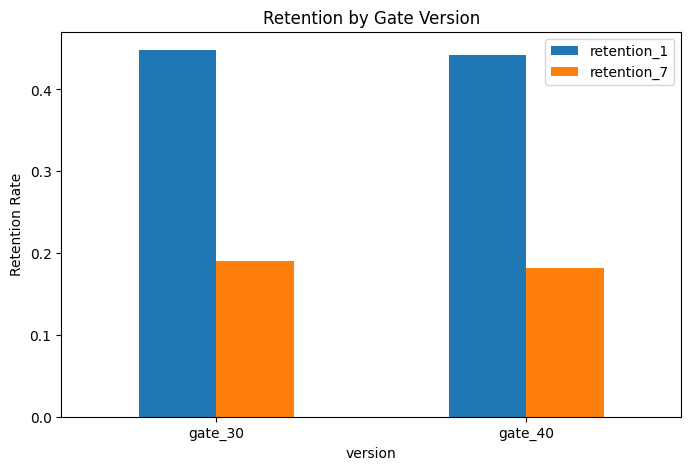

In [8]:
import matplotlib.pyplot as plt

summary.plot(kind='bar', figsize=(8,5), title='Retention by Gate Version')
plt.ylabel('Retention Rate')
plt.xticks(rotation=0)
plt.show()

In [9]:
print(df.groupby('version')['sum_gamerounds'].agg(['mean','median']))

group_30_r1 = pd.crosstab(df['version'], df['retention_1'])
chi2_r1, p_r1 = stats.chi2_contingency(group_30_r1)[:2]
print('retention_1 p-value:', p_r1)

              mean  median
version                   
gate_30  52.456264    17.0
gate_40  51.298776    16.0
retention_1 p-value: 0.07550476210309086
